In [ ]:
# using both vikasukani and dipayanbiswas datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, auc

loading the dataset

In [ ]:
df1 = pd.read_csv("/content/parkinsons.data")
df1 = df1.drop(columns=['name'], errors='ignore')
df1['source'] = 'vikasukani'

df2 = pd.read_csv("/content/pd_speech_features.csv")
label_col = 'class' if 'class' in df2.columns else 'status'
df2 = df2.rename(columns={label_col: 'status'})
df2['source'] = 'dipayanbiswas'

Combine datasets with UNION of columns

In [ ]:
df_combined = pd.concat([df1, df2], ignore_index=True, sort=False)

Handle missing values by filling with mean

In [ ]:
df_combined.fillna(df_combined.mean(numeric_only=True), inplace=True)

Drop 'source' column for modeling

In [ ]:
df_combined = df_combined.drop(columns=['source'], errors='ignore')

Preview dataset shape

In [ ]:
combined_shape = df_combined.shape

Check for nulls

In [ ]:
null_counts = df_combined.isnull().sum()

Statistical summary

In [ ]:
stat_summary = df_combined.describe()

pd.set_option('display.max_columns', 100)  # show more columns
df_combined.describe().T  # transpose for better vertical view

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),951.0,154.228641,18.704029,88.333000,154.228641,154.228641,154.228641,260.10500
MDVP:Fhi(Hz),951.0,197.104918,41.344718,102.145000,197.104918,197.104918,197.104918,592.03000
MDVP:Flo(Hz),951.0,116.324631,19.667178,65.476000,116.324631,116.324631,116.324631,239.17000
MDVP:Jitter(%),951.0,0.006220,0.002191,0.001680,0.006220,0.006220,0.006220,0.03316
MDVP:Jitter(Abs),951.0,0.000044,0.000016,0.000007,0.000044,0.000044,0.000044,0.00026
...,...,...,...,...,...,...,...,...
tqwt_kurtosisValue_dec_32,951.0,12.218953,15.853763,1.789500,3.114150,5.950000,12.218953,85.57170
tqwt_kurtosisValue_dec_33,951.0,12.375335,14.568270,1.628700,3.344350,7.185900,12.375335,73.53220
tqwt_kurtosisValue_dec_34,951.0,14.799230,14.016298,1.861700,4.275750,11.035100,15.404300,62.00730
tqwt_kurtosisValue_dec_35,951.0,14.751559,12.866714,1.955900,4.226150,13.229900,17.131050,57.54430


Target value distribution

In [ ]:
target_dist = df_combined['status'].value_counts()

Feature-target split

In [ ]:
X = df_combined.drop('status', axis=1)
y = df_combined['status']

Model train

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k-NN:

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_knn_pred = knn_model.predict(X_test_scaled)

Random Forest:

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_rf_pred = rf_model.predict(X_test_scaled)

XGBoost

In [ ]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train)
y_xgb_pred = xgb_model.predict(X_test_scaled)
y_xgb_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:43:37] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Evaluate both models

In [ ]:
knn_accuracy = accuracy_score(y_test, y_knn_pred)
rf_accuracy = accuracy_score(y_test, y_rf_pred)
xgb_accuracy = accuracy_score(y_test, y_xgb_pred)

knn_report = classification_report(y_test, y_knn_pred, output_dict=True)
rf_report = classification_report(y_test, y_rf_pred, output_dict=True)
xgb_report = classification_report(y_test, y_xgb_pred, output_dict=True)

f1 score

In [ ]:
knn_f1 = f1_score(y_test, y_knn_pred)
rf_f1 = f1_score(y_test, y_rf_pred)
xgb_f1 = f1_score(y_test, y_xgb_pred)

Compare precision for class 1 (PD)

/tmp/ipython-input-19-239403348.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='crest')


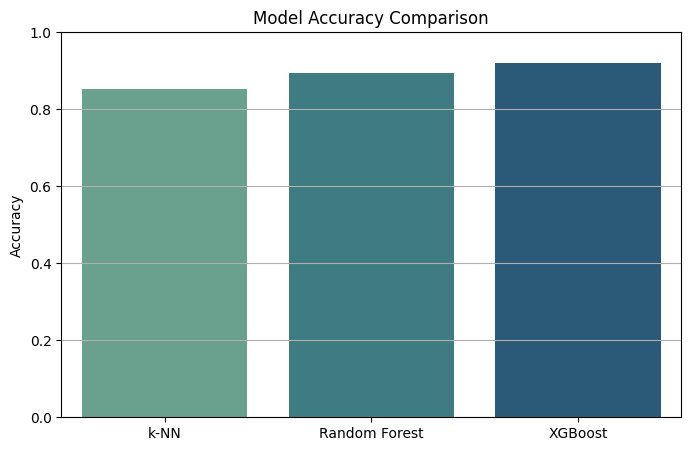

/tmp/ipython-input-19-239403348.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=precisions, palette='flare')


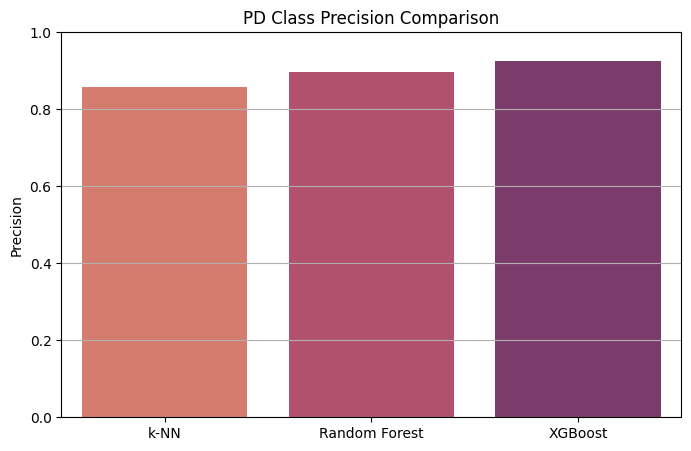

/tmp/ipython-input-19-239403348.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=f1_scores, palette='viridis')


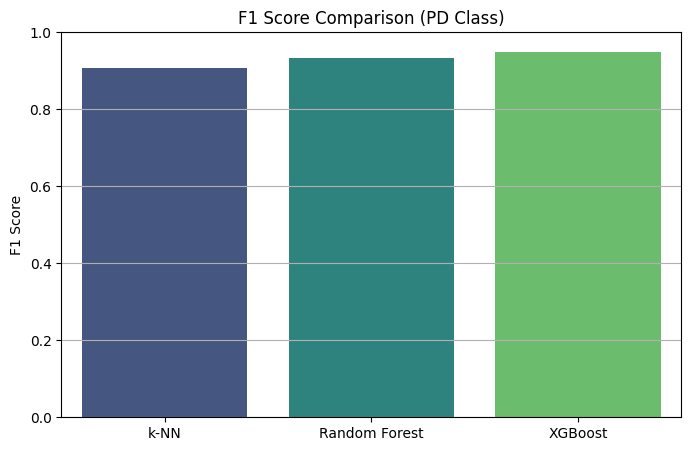

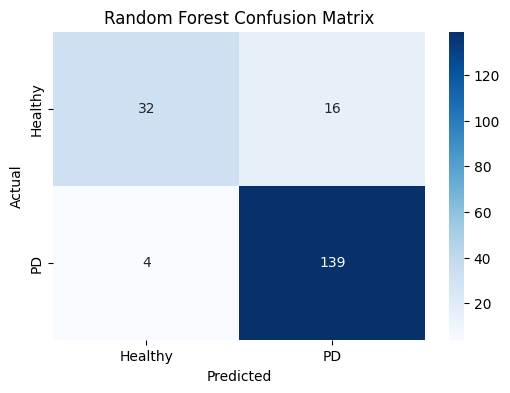

In [ ]:
knn_precision = knn_report['1']['precision']
rf_precision = rf_report['1']['precision']
xgb_precision = xgb_report['1']['precision']

df_combined.head()

combined_shape, null_counts, stat_summary, target_dist, knn_accuracy, rf_accuracy, knn_precision, rf_precision

# Accuracy Comparison
model_names = ['k-NN', 'Random Forest', 'XGBoost']
accuracies = [knn_accuracy, rf_accuracy, xgb_accuracy]
precisions = [knn_precision, rf_precision, xgb_precision]
f1_scores = [knn_f1, rf_f1, xgb_f1]

# Bar plot: Accuracy
plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=accuracies, palette='crest')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

# Bar plot: Precision (PD Class)
plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=precisions, palette='flare')
plt.title('PD Class Precision Comparison')
plt.ylabel('Precision')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

#F1 score plot
plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=f1_scores, palette='viridis')
plt.title('F1 Score Comparison (PD Class)')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

# Confusion matrix for Random Forest
rf_cm = confusion_matrix(y_test, y_rf_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'PD'], yticklabels=['Healthy', 'PD'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

roc and auc curve

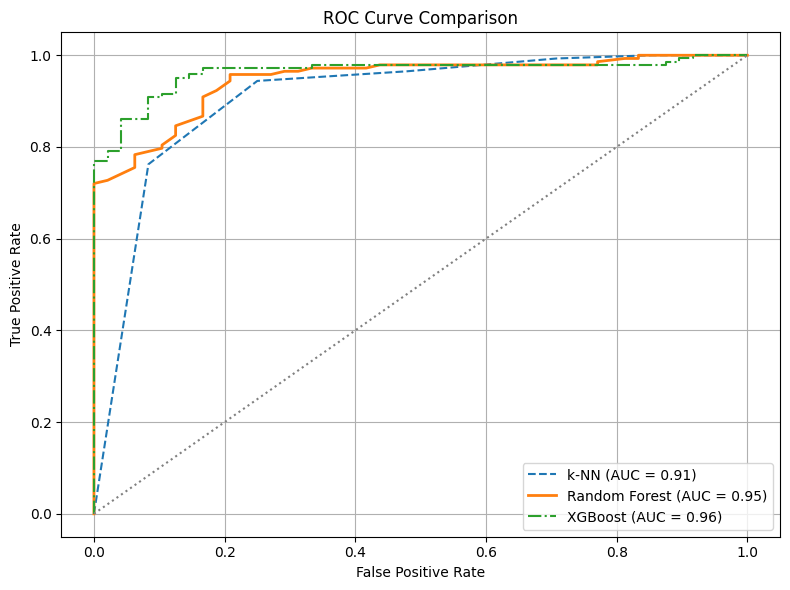

In [ ]:
# Predict probabilities for ROC curve
y_knn_proba = knn_model.predict_proba(X_test_scaled)[:, 1]
y_rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve and AUC for k-NN
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_knn_proba)
roc_auc_knn = auc(fpr_knn, tpr_knn)

# Compute ROC curve and AUC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_rf_proba)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# ROC Curve for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_xgb_proba)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Add XGBoost to ROC plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, label=f'k-NN (AUC = {roc_auc_knn:.2f})', linestyle='--')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})', linestyle='-.')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print("Shape:", combined_shape)
print("\nNull Counts:\n", null_counts)
print("\nTarget Distribution:\n", target_dist)
print("\nk-NN Accuracy:", knn_accuracy, "| Precision (PD):", knn_precision)
print("Random Forest Accuracy:", rf_accuracy, "| Precision (PD):", rf_precision)
print(f"XGBoost     → Accuracy: {xgb_accuracy}, Precision: {xgb_precision}, F1 Score: {xgb_f1}")
print(knn_f1, rf_f1, xgb_f1)

Shape: (951, 774)

Null Counts:
 MDVP:Fo(Hz)                  0
MDVP:Fhi(Hz)                 0
MDVP:Flo(Hz)                 0
MDVP:Jitter(%)               0
MDVP:Jitter(Abs)             0
                            ..
tqwt_kurtosisValue_dec_32    0
tqwt_kurtosisValue_dec_33    0
tqwt_kurtosisValue_dec_34    0
tqwt_kurtosisValue_dec_35    0
tqwt_kurtosisValue_dec_36    0
Length: 774, dtype: int64

Target Distribution:
 status
1    711
0    240
Name: count, dtype: int64

k-NN Accuracy: 0.8534031413612565 | Precision (PD): 0.8571428571428571
Random Forest Accuracy: 0.8952879581151832 | Precision (PD): 0.896774193548387
XGBoost     → Accuracy: 0.9214659685863874, Precision: 0.9266666666666666, F1 Score: 0.9488054607508533
0.9078947368421053 0.9328859060402684 0.9488054607508533
